# DC1000 Ground-Truth Overlay by Filename

Notebook này cho phép nhập tên ảnh trong bộ dữ liệu DC1000 và hiển thị ảnh gốc cùng ground-truth mask chồng màu đỏ với độ trong suốt tùy chỉnh.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['figure.dpi'] = 100

DC1000 = '../data/DC1000'

## Cách sử dụng

1. Đổi giá trị `image_name` thành tên ảnh cần xem, ví dụ `000015.png`.
2. Điều chỉnh `overlay_alpha` trong khoảng từ `0.0` đến `1.0`.
3. Chạy cell bên dưới để hiển thị ảnh gốc và ảnh overlay ground-truth mask.

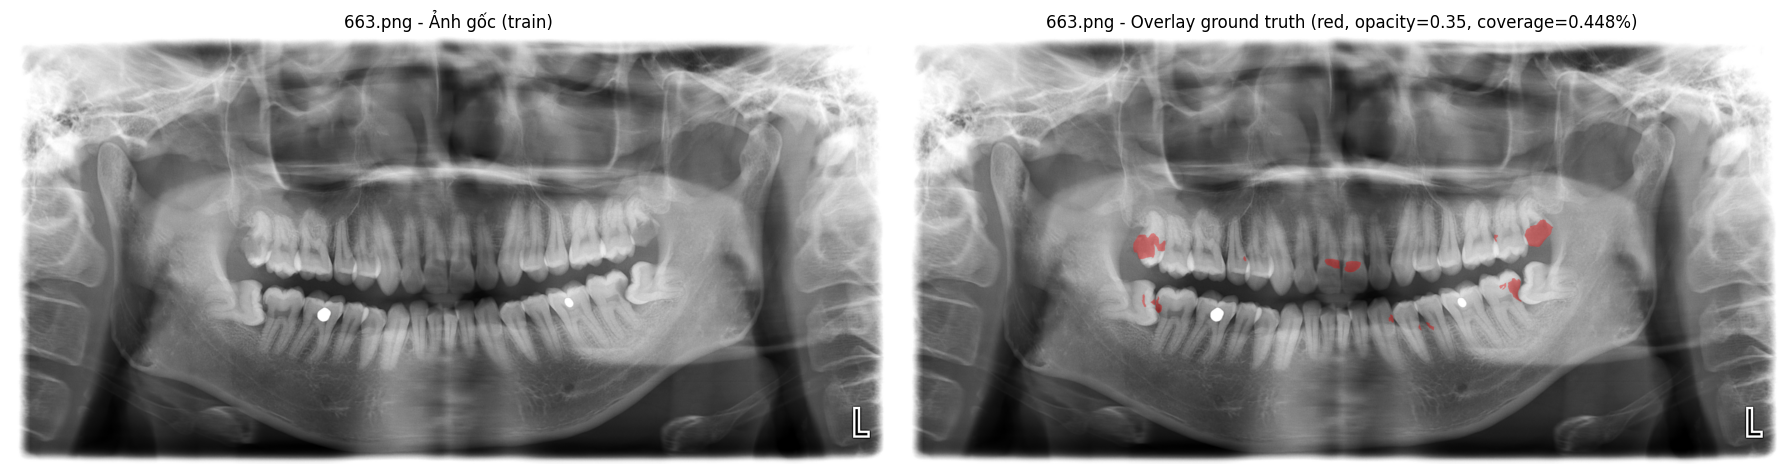

Split: train
Image path: ../data/DC1000/train/images/663.png
Mask path: ../data/DC1000/train/masks/663.png
Caries coverage: 0.448%


In [6]:
image_name = '663.png'
overlay_alpha = 0.35  # 0.0 = chỉ ảnh gốc, 1.0 = đỏ hoàn toàn

match = None
for split in ['train', 'valid', 'test']:
    candidate_img = os.path.join(DC1000, split, 'images', image_name)
    candidate_mask = os.path.join(DC1000, split, 'masks', image_name)
    if os.path.exists(candidate_img) and os.path.exists(candidate_mask):
        match = (split, candidate_img, candidate_mask)
        break

if match is None:
    raise FileNotFoundError(f'Không tìm thấy {image_name} trong train/valid/test.')

split, image_path, mask_path = match
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError(f'Không đọc được ảnh: {image_path}')

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
if mask is None:
    raise ValueError(f'Không đọc được mask: {mask_path}')

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
mask_bool = mask > 127

red_overlay = np.zeros_like(img_rgb)
red_overlay[..., 0] = 255
overlay_rgb = img_rgb.copy()
overlay_rgb[mask_bool] = (
    (1 - overlay_alpha) * img_rgb[mask_bool] + overlay_alpha * red_overlay[mask_bool]
).astype(np.uint8)

coverage = mask_bool.sum() / mask.size * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(img_rgb)
axes[0].set_title(f'{image_name} - Ảnh gốc ({split})')
axes[0].axis('off')

axes[1].imshow(overlay_rgb)
axes[1].set_title(
    f'{image_name} - Overlay ground truth (red, opacity={overlay_alpha:.2f}, coverage={coverage:.3f}%)'
)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'Split: {split}')
print(f'Image path: {image_path}')
print(f'Mask path: {mask_path}')
print(f'Caries coverage: {coverage:.3f}%')